In [1]:
import pandas as pd

df = pd.read_csv("sales.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,INDMKB,8/11/2020,11/11/2020,sas,as,asa,asa,asas,asas,...,42420.0,INDMKB,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,8/11/2020,11/11/2020,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,12/6/2020,16/6/2020,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,11/10/2019,18/10/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,11/10/2019,18/10/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   int64  
 1   Order ID        9994 non-null   str    
 2   Order Date      9994 non-null   str    
 3   Ship Date       9994 non-null   str    
 4   Ship Mode       9994 non-null   str    
 5   Customer ID     9994 non-null   str    
 6   Customer Name   9994 non-null   str    
 7   Segment         9994 non-null   str    
 8   Country/Region  9994 non-null   str    
 9   City            9994 non-null   str    
 10  State           9994 non-null   str    
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   str    
 13  Product ID      9994 non-null   str    
 14  Category        9994 non-null   str    
 15  Sub-Category    9994 non-null   str    
 16  Product Name    9994 non-null   str    
 17  Sales           9994 non-null   float64
 18 

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Data Cleaning

In [3]:
df = df.drop_duplicates()

In [4]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [5]:
df['Postal Code'] = df['Postal Code'].fillna(0)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

In [6]:
df['Sales'].describe()
df['Profit'].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

In [7]:
df = df[df['Sales'] > 0]
df = df[df['Quantity'] > 0]

In [8]:
#
df.loc[(df['City'] == 'Burlington') & (df['Postal Code'].isnull()), 'Postal Code'] = 5401

print("missing values in postal code column:", df['Postal Code'].isnull().sum())

missing values in postal code column: 0


In [9]:
#
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9994 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2020-04-30 00:07:03.614168,2020-05-03 23:06:58.571142,55184.427056,229.858001,3.789574,0.156203,28.656896
min,1.000000,2018-01-03 00:00:00,2018-01-07 00:00:00,0.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2019-05-23 00:00:00,2019-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2020-06-26 00:00:00,2020-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2021-05-14 00:00:00,2021-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2021-12-30 00:00:00,2022-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32073.435974,623.245101,2.225110,0.206452,234.260108


In [10]:
#
df['Postal Code'] = df['Postal Code'].astype(int)

In [11]:
#
df.duplicated().sum()
df = df.drop_duplicates()
print("number of duplicated rows after dropping duplicates:", df.duplicated().sum())

number of duplicated rows after dropping duplicates: 0


In [12]:
invalid_sales = df[df['Sales'] <= 0]
invalid_quantity = df[df['Quantity'] <= 0]


df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

invalid_dates = df[(pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce').isnull()) | 
                   (pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce').isnull())]

print(invalid_dates)

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country/Region, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


Feature Engineering

In [13]:
df['Month'] = df['Order Date'].dt.to_period('M')
df['year'] = df['Order Date'].dt.year
df['Sales_per_Order'] = df['Sales'] / df['Quantity']

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,year,Sales_per_Order
0,1,INDMKB,2020-11-08,2020-11-11,sas,as,asa,asa,asas,asas,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2020-11,2020,130.9800
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2020-11,2020,243.9800
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2020-06,2020,7.3100
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2019-10,2019,191.5155
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2019-10,2019,11.1840


In [15]:
customer_orders = df.groupby('Customer ID')['Order Date'].nunique()

df['repeat_customer'] = df['Customer ID'].map(
    lambda x: 1 if customer_orders[x] > 1 else 0)

customer_orders

Customer ID
AA-10315     5
AA-10375     9
AA-10480     4
AA-10645     6
AB-10015     3
            ..
YC-21895     5
YS-21880     8
ZC-21910    13
ZD-21925     5
as           1
Name: Order Date, Length: 794, dtype: int64

Active vs Inactive Customers

In [16]:

last_date = df[ 'Order Date'] .max()
cutoff_date = last_date - pd.Timedelta(days=30)
last_purchase = df.groupby('Customer ID')['Order Date'].max()
df['Active_Customer'] = df['Customer ID'].map(
    lambda x: 1 if last_purchase[x] > cutoff_date else 0)

print(df['Active_Customer'].value_counts())
print(df['repeat_customer'].value_counts())


Active_Customer
0    7185
1    2809
Name: count, dtype: int64
repeat_customer
1    9966
0      28
Name: count, dtype: int64


In [17]:
recent_date = df['Order Date'].max()

df['Active'] = df.groupby('Customer ID')['Order Date'].transform(lambda x: (recent_date - x.max()).days <= 90)
active_customers = df[df['Active'] == True]['Customer ID'].nunique()
inactive_customers = df[df['Active'] == False]['Customer ID'].nunique()

print(f"Active Customers: {active_customers}")
print(f"Inactive Customers: {inactive_customers}")

Active Customers: 436
Inactive Customers: 358


In [18]:
df = df.drop(df.index[0])
df = df.reset_index(drop=True)

In [19]:
print(df['Ship Mode'].unique())

<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str


KPIs

In [20]:
active_customers_monthly = df.groupby('Month')['Customer ID'].nunique()

In [21]:
aov = df['Sales'].sum() / df['Order ID'].nunique()

In [22]:
ltv = df.groupby('Customer ID')['Sales'].sum().mean()

In [23]:
first_purchase = df.groupby('Customer ID')['Order Date'].min()
df['First Purchase'] = df['Customer ID'].map(first_purchase)
df['First Purchase Month'] = df['First Purchase'].dt.to_period('M')

new_customers_monthly = df[df['Month'] == df['First Purchase Month']] \
                        .groupby('Month')['Customer ID'].nunique()

In [24]:
customers_by_month = df.groupby('Month')['Customer ID'].apply(set)

churned = {}
months = sorted(customers_by_month.index)

for i in range(1, len(months)):
    prev = customers_by_month[months[i-1]]
    curr = customers_by_month[months[i]]
    churned[months[i]] = len(prev - curr)

In [25]:
monthly_customers = df.groupby('Month')['Customer ID'].nunique()



In [26]:
# make sure base variables are defined before using them
if 'customers_by_month' not in globals():
    customers_by_month = df.groupby('Month')['Customer ID'].apply(set)

months = sorted(customers_by_month.index)

retention_rate = {}
for i in range(1, len(months)):
    prev = customers_by_month[months[i-1]]
    curr = customers_by_month[months[i]]
    retention_rate[months[i]] = len(prev & curr) / len(prev) if len(prev) > 0 else 0

retention_rate = pd.Series(retention_rate)

In [27]:
df['new_customer'] = (df['Month'] == df['First Purchase Month']).astype(int)


In [28]:
# Create a DataFrame of unique customer-month pairs
customers_by_month = df[['Customer ID', 'Month']].drop_duplicates().reset_index(drop=True)
 
# Add a column for the previous month
customers_by_month['prev_month'] = customers_by_month['Month'] - 1

# Merge to find customers who were present in the previous month but not in the current
merged = customers_by_month.merge(
    customers_by_month,
    left_on=['Customer ID', 'prev_month'],
    right_on=['Customer ID', 'Month'], 
    how='left',
    indicator=True
)

# Churned customers are those in the left merge (present in prev month but not current)
churned = merged[merged['_merge'] == 'left_only']

Product Analysis

In [29]:

# Top Products

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

In [30]:
# Top Categories

top_categories = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

In [31]:
# Repeat Customers

repeat_customers = df.groupby('Customer ID')['Order ID'].nunique()
repeat_customers = repeat_customers[repeat_customers > 1]

In [32]:
# New Customers

first_purchase = df.groupby('Customer ID')['Order Date'].min()

df['First Purchase'] = df['Customer ID'].map(first_purchase)

new_customers = df[df['Order Date'] == df['First Purchase']]['Customer ID'].nunique()

In [33]:
# Customers per Month

df['Month'] = df['Order Date'].dt.to_period('M')

customers_per_month = df.groupby('Month')['Customer ID'].unique()

In [34]:
df.to_csv("final_dataset.csv", index=False)
top_products = top_products.reset_index()
top_products.to_csv("top_products.csv", index=False)

In [35]:
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (df['Order Date'].max() - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

Visualization

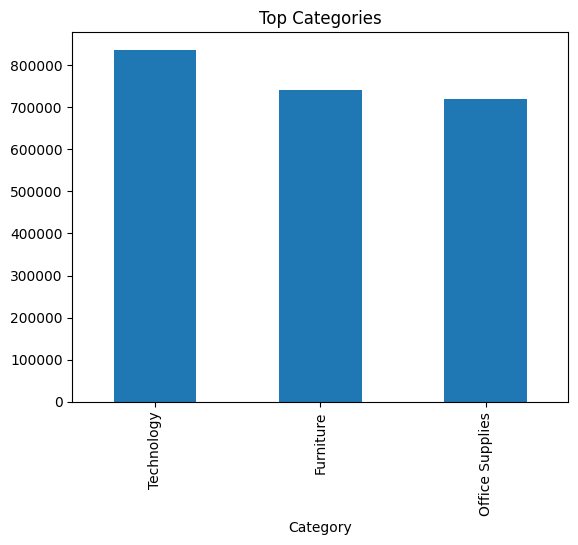

In [36]:
import matplotlib.pyplot as plt

top_categories.plot(kind='bar')
plt.title("Top Categories")
plt.show()

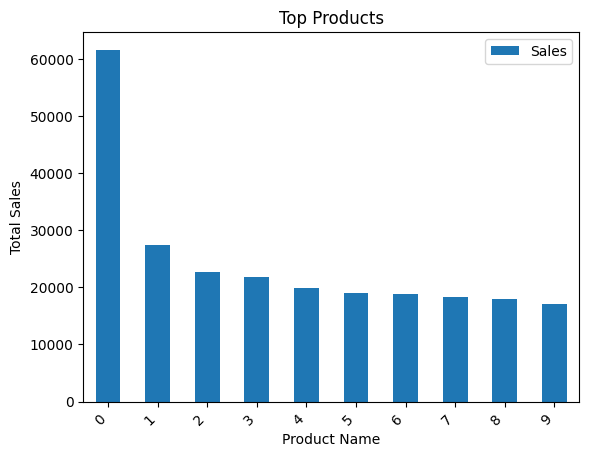

In [37]:
top_products.plot(kind='bar')
plt.title("Top Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.show()

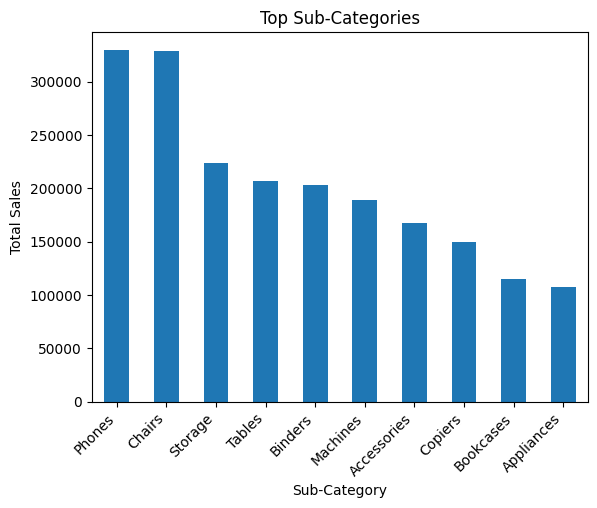

In [38]:
sup_categories = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
sup_categories.plot(kind='bar')
plt.title("Top Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.show()

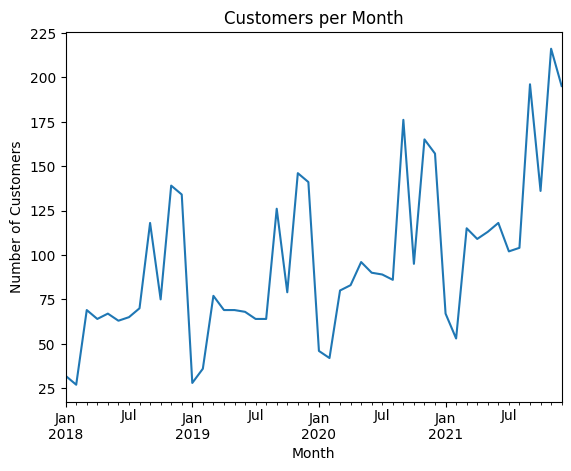

In [39]:
customers_per_month.apply(len).plot(kind='line')
plt.title("Customers per Month")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.show()

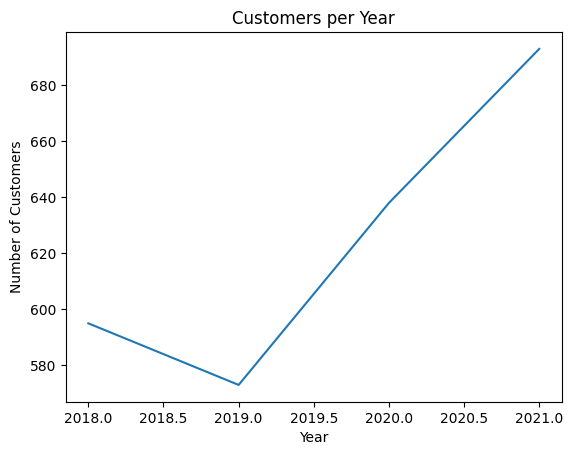

In [40]:
customers_per_year = df.groupby(df['Order Date'].dt.year)['Customer ID'].nunique()
customers_per_year.plot(kind='line')
plt.title("Customers per Year")
plt.xlabel("Year")
plt.ylabel("Number of Customers")
plt.show()

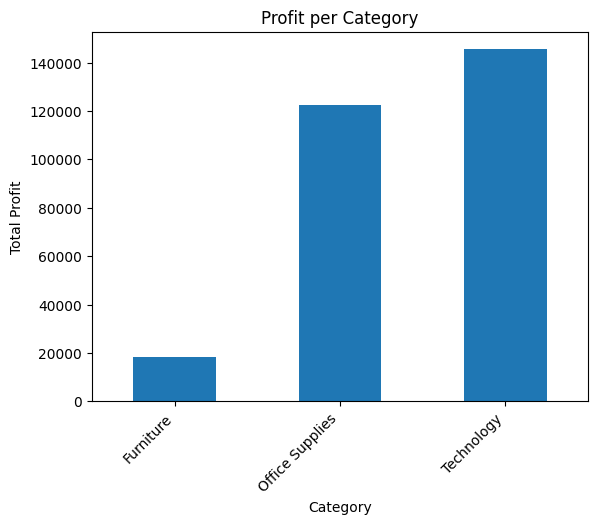

In [41]:
profit_per_category = df.groupby('Category')['Profit'].sum()
profit_per_category.plot(kind='bar')
plt.title("Profit per Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha='right')
plt.show()

In [42]:
df['Order_Month'] = df['Order Date'].dt.to_period('M')

# 2. تحديد أول شهر شراء لكل عميل (الـ Cohort)
df['Cohort'] = df.groupby('Customer ID')['Order_Month'].transform('min')

# 3. دالة لحساب الفرق بالشهور (Cohort Index)
def cohort_index(row):
    year_diff = row['Order_Month'].year - row['Cohort'].year
    month_diff = row['Order_Month'].month - row['Cohort'].month
    return year_diff * 12 + month_diff

df['Cohort_Index'] = df.apply(cohort_index, axis=1)

In [43]:
# تجميع البيانات
cohort_data = df.groupby(['Cohort', 'Cohort_Index'])['Customer ID'].nunique().reset_index()

# عمل الجدول المحوري (Pivot)
cohort_pivot = cohort_data.pivot(index='Cohort', columns='Cohort_Index', values='Customer ID')

# حساب النسبة المئوية (Retention Rate)
cohort_size = cohort_pivot.iloc[:, 0] # أول عمود هو إجمالي عدد العملاء في البداية
retention = cohort_pivot.divide(cohort_size, axis=0)

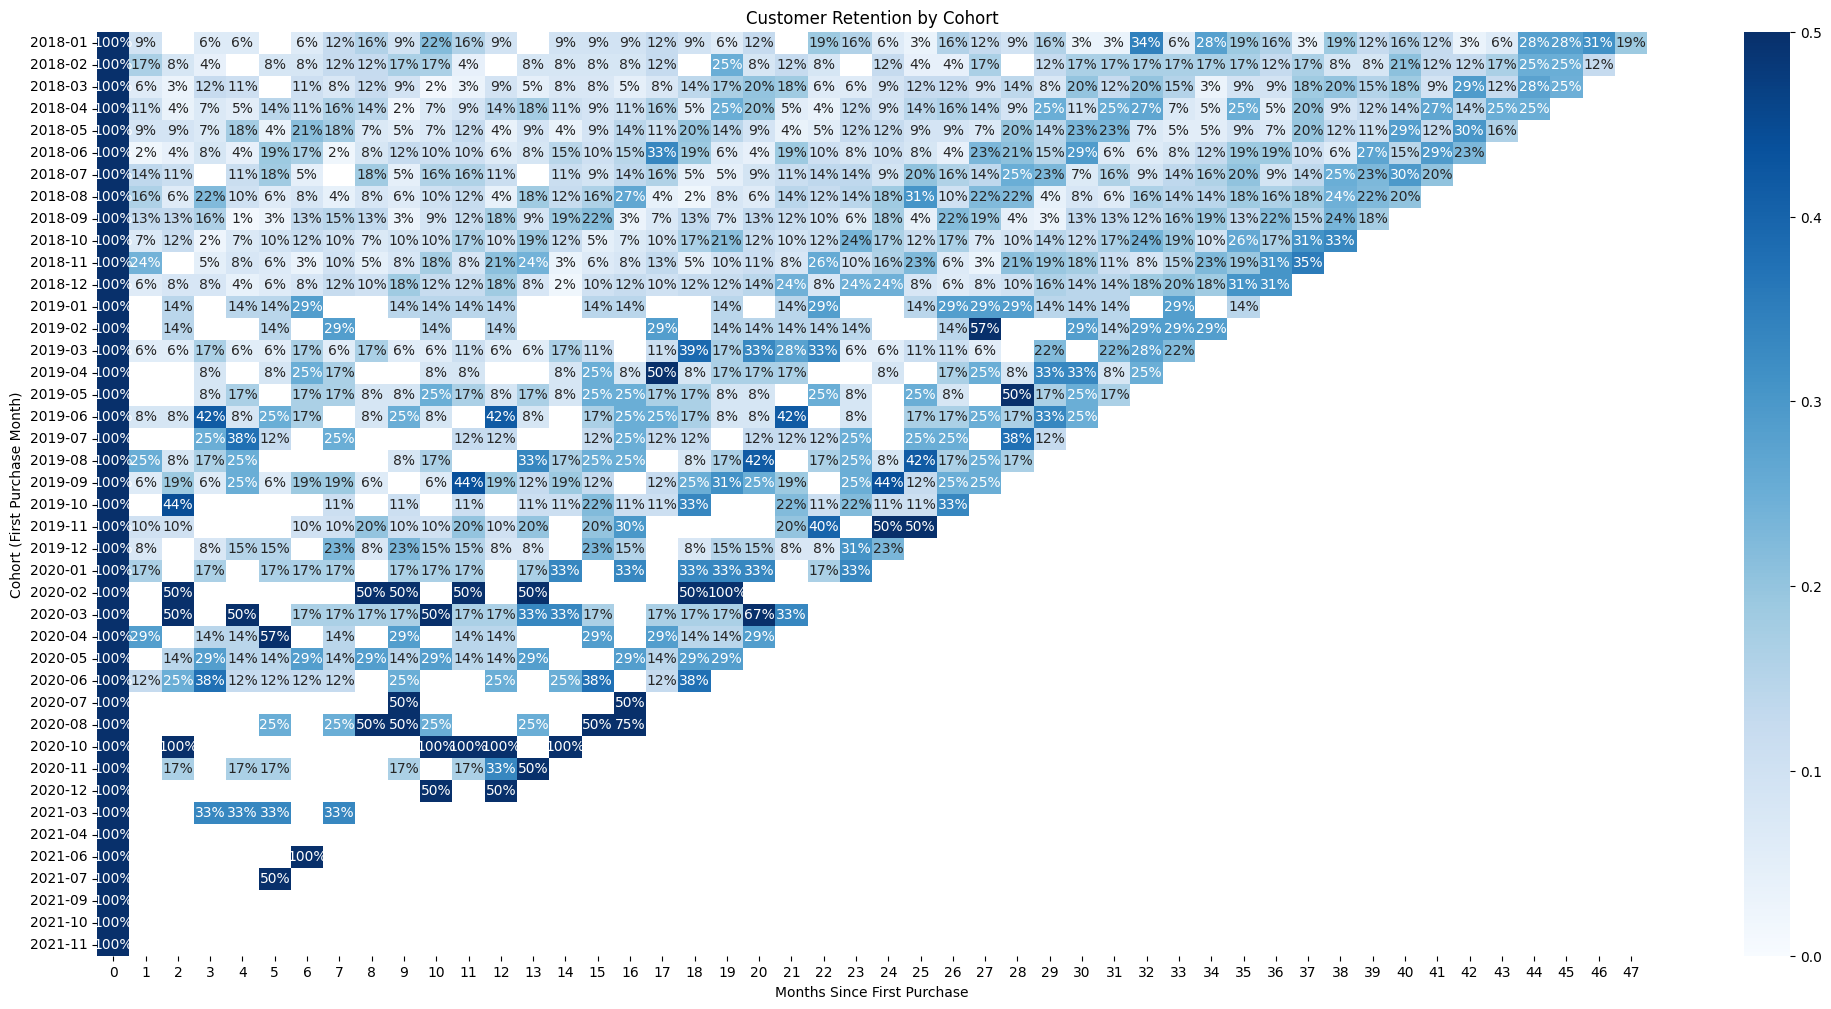

In [44]:
import seaborn as sns

plt.figure(figsize=(25, 12)) # كبرت الحجم عشان الأرقام تبان
sns.heatmap(data=retention, 
            annot=True, 
            fmt=".0%",
            vmin=0.0, 
            vmax=0.5,
            cmap="Blues")

plt.title("Customer Retention by Cohort")
plt.ylabel("Cohort (First Purchase Month)")
plt.xlabel("Months Since First Purchase")
plt.show()

In [45]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales_per_Order,repeat_customer,Active_Customer,Active,First Purchase,First Purchase Month,new_customer,Order_Month,Cohort,Cohort_Index
0,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,243.9800,1,0,False,2019-10-15,2019-10,0,2020-11,2019-10,13
1,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,7.3100,1,1,True,2020-06-12,2020-06,1,2020-06,2020-06,0
2,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,191.5155,1,1,True,2019-10-11,2019-10,1,2019-10,2019-10,0
3,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,11.1840,1,1,True,2019-10-11,2019-10,1,2019-10,2019-10,0
4,6,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,6.9800,1,1,True,2018-06-09,2018-06,1,2018-06,2018-06,0
